In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wcwidth import width

In [2]:
data = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [4]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [7]:
data['Date'].unique().size

3653

In [8]:
data['Company'].unique()


array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [9]:
data['Event'].unique()

array([nan, 'Cloud AI launch', 'AI ethics policy update',
       'AI-powered search update', 'AI Ads Optimization upgrade',
       'AI partnership deal', 'AI Video Recommendation upgrade',
       'AI speech recognition release', 'GPT-1 release', 'GPT-2 release',
       'GPT-3 release', 'Codex release', 'DALL·E 2 release',
       'ChatGPT (GPT-3.5) launch', 'GPT-4 release',
       'GPT-5 release (predicted)', 'TensorFlow open-source release',
       'AlphaGo beats Lee Sedol', 'BERT for Search launch',
       'MUM Search Model launch', 'Bard chatbot launch',
       'Gemini AI release', 'LLaMA 1 release', 'LLaMA 2 release',
       'LLaMA 3 release (predicted)'], dtype=object)

In [11]:
data.isnull().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
dtype: int64

In [12]:
data['Date'] = pd.to_datetime(data['Date'])

In [13]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [14]:
data['Year'] = data['Date'].dt.year

In [15]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [16]:
data['Year'].unique().size

10

In [29]:
RD = data.groupby('Company')['R&D_Spending_USD_Mn'].sum().sort_values(ascending=False)
RD = RD.reset_index()
RD

,Company,R&D_Spending_USD_Mn
0,Google,423341.14
1,Meta,264533.07
2,OpenAI,26482.77


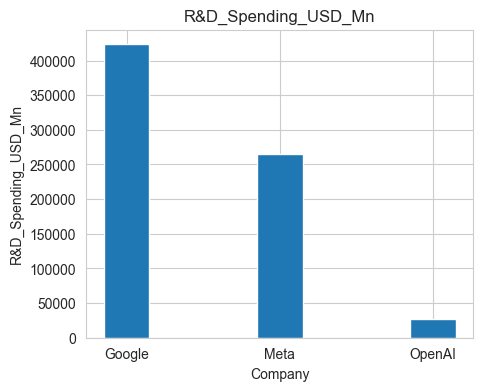

In [32]:
plt.figure(figsize=(5,4))
plt.bar(RD['Company'], RD['R&D_Spending_USD_Mn'], width= 0.3)
plt.title('R&D_Spending_USD_Mn')
plt.xlabel('Company')
plt.ylabel('R&D_Spending_USD_Mn')
plt.show()

In [19]:
data.head(3)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015


In [33]:
Rev = data.groupby('Company')['AI_Revenue_USD_Mn'].sum().sort_values(ascending=False)
Rev = Rev.reset_index()
Rev

,Company,AI_Revenue_USD_Mn
0,Google,284498.38
1,Meta,189621.82
2,OpenAI,9462.89


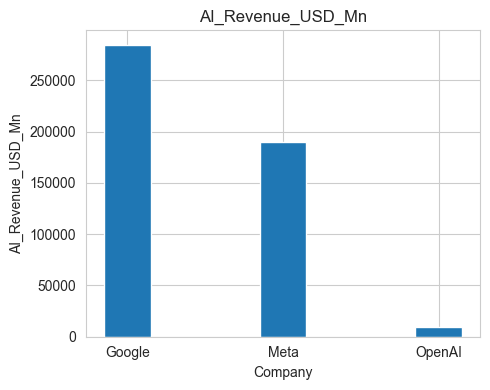

In [61]:
plt.figure(figsize=(5,4))
plt.bar(Rev['Company'], Rev['AI_Revenue_USD_Mn'], width= 0.3)
plt.title('AI_Revenue_USD_Mn')
plt.xlabel('Company')
plt.ylabel('AI_Revenue_USD_Mn')
plt.tight_layout()
plt.show()

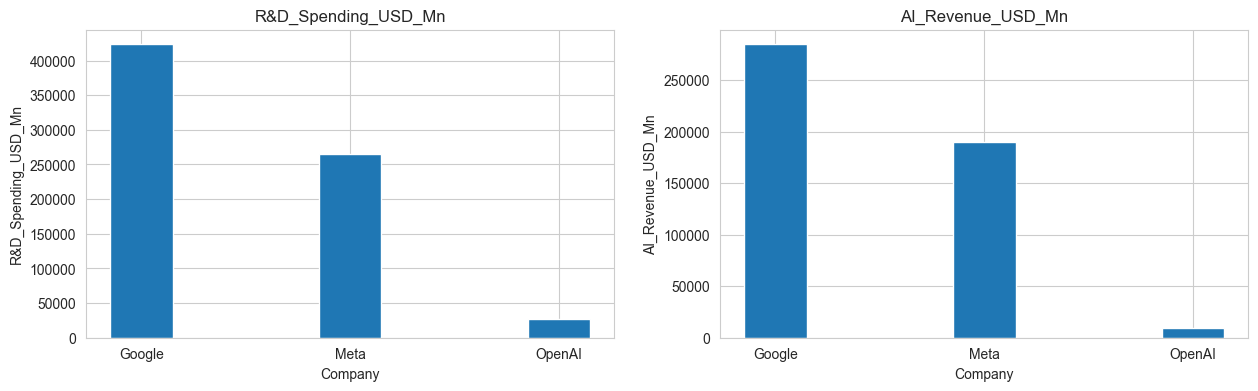

In [59]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.bar(RD['Company'], RD['R&D_Spending_USD_Mn'], width= 0.3)
plt.title('R&D_Spending_USD_Mn')
plt.xlabel('Company')
plt.ylabel('R&D_Spending_USD_Mn')

plt.subplot(1, 2, 2)
plt.bar(Rev['Company'], Rev['AI_Revenue_USD_Mn'], width= 0.3)
plt.title('AI_Revenue_USD_Mn')
plt.xlabel('Company')
plt.ylabel('AI_Revenue_USD_Mn')

plt.show()

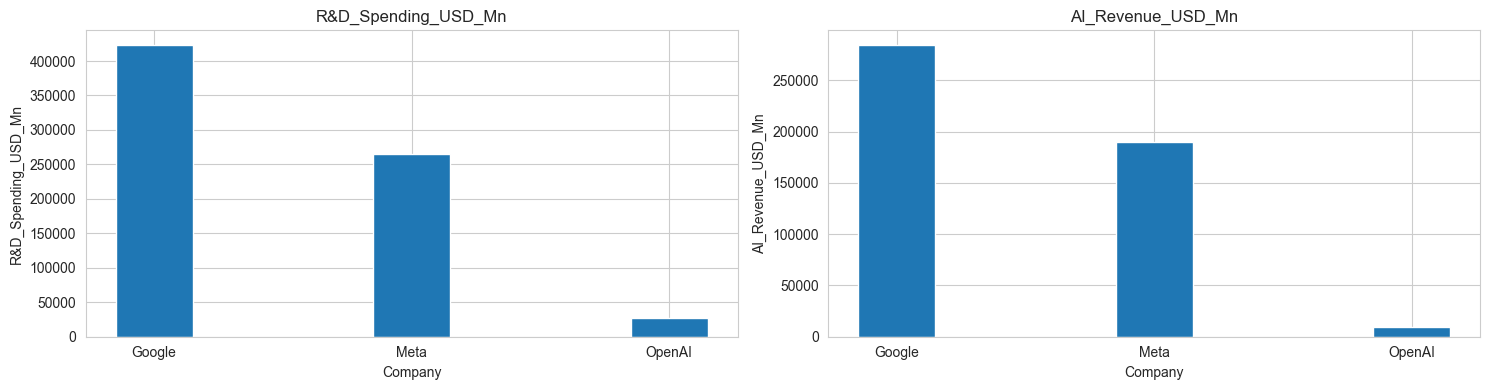

In [60]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.bar(RD['Company'], RD['R&D_Spending_USD_Mn'], width= 0.3)
plt.title('R&D_Spending_USD_Mn')
plt.xlabel('Company')
plt.ylabel('R&D_Spending_USD_Mn')

plt.subplot(1, 2, 2)
plt.bar(Rev['Company'], Rev['AI_Revenue_USD_Mn'], width= 0.3)
plt.title('AI_Revenue_USD_Mn')
plt.xlabel('Company')
plt.ylabel('AI_Revenue_USD_Mn')

plt.tight_layout()
plt.show()

In [62]:
data.head(3)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015


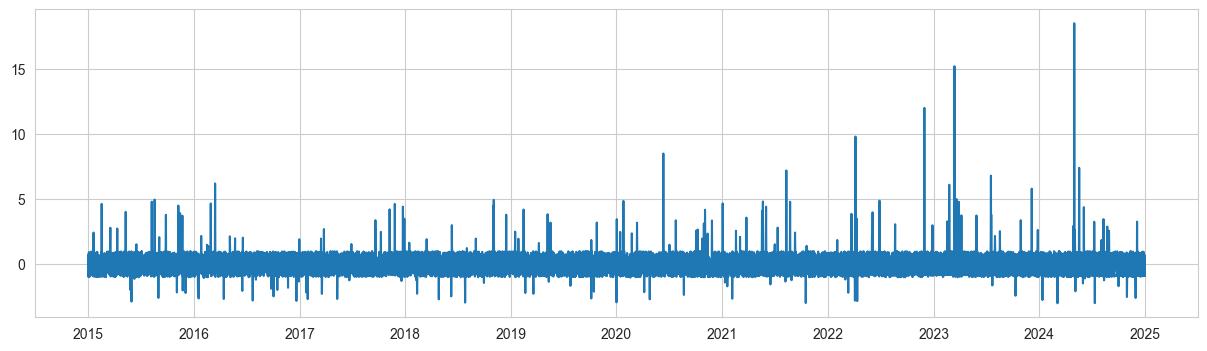

In [65]:
plt.figure(figsize=(15,4))
plt.plot(data['Date'], data['Stock_Impact_%'])
plt.show()

In [66]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [67]:
data['Company'].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [68]:
openAI = data[data['Company'] == 'OpenAI']

In [69]:
google = data[data['Company'] == 'Google']

In [70]:
meta = data[data['Company'] == 'Meta']

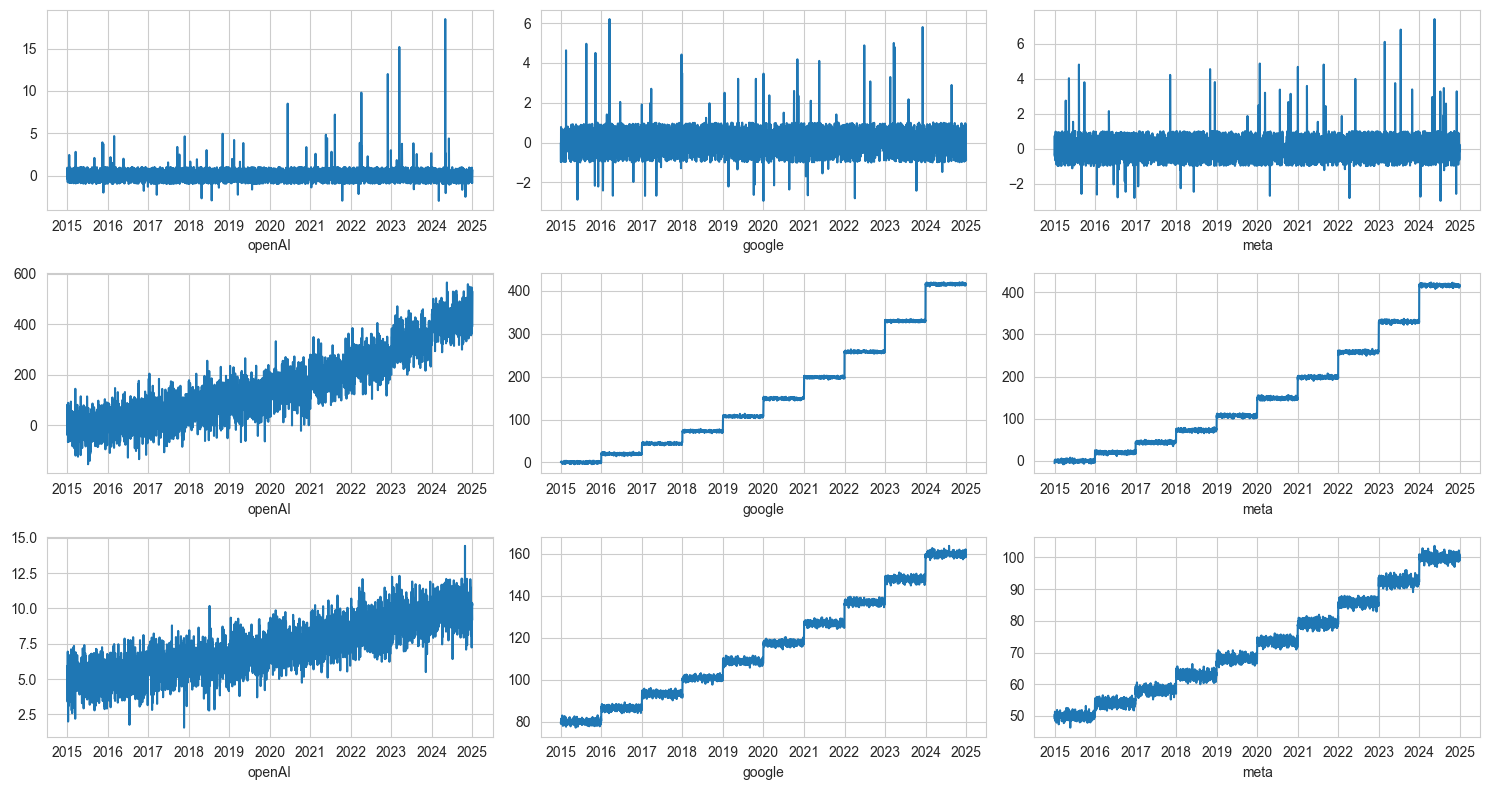

In [78]:
plt.figure(figsize=(15,8))

plt.subplot(3,3,1)
plt.plot(openAI['Date'], openAI['Stock_Impact_%'])
plt.xlabel('openAI')

plt.subplot(3,3,2)
plt.plot(google['Date'], google['Stock_Impact_%'])
plt.xlabel('google')

plt.subplot(3,3,3)
plt.plot(meta['Date'], meta['Stock_Impact_%'])
plt.xlabel('meta')

plt.subplot(3,3,4)
plt.plot(openAI['Date'], openAI['AI_Revenue_Growth_%'])
plt.xlabel('openAI')

plt.subplot(3,3,5)
plt.plot(google['Date'], google['AI_Revenue_Growth_%'])
plt.xlabel('google')

plt.subplot(3,3,6)
plt.plot(meta['Date'], meta['AI_Revenue_Growth_%'])
plt.xlabel('meta')

plt.subplot(3,3,7)
plt.plot(openAI['Date'], openAI['R&D_Spending_USD_Mn'])
plt.xlabel('openAI')

plt.subplot(3,3,8)
plt.plot(google['Date'], google['R&D_Spending_USD_Mn'])
plt.xlabel('google')

plt.subplot(3,3,9)
plt.plot(meta['Date'], meta['R&D_Spending_USD_Mn'])
plt.xlabel('meta')



plt.tight_layout()
plt.show()


<Axes: xlabel='Date', ylabel='AI_Revenue_Growth_%'>

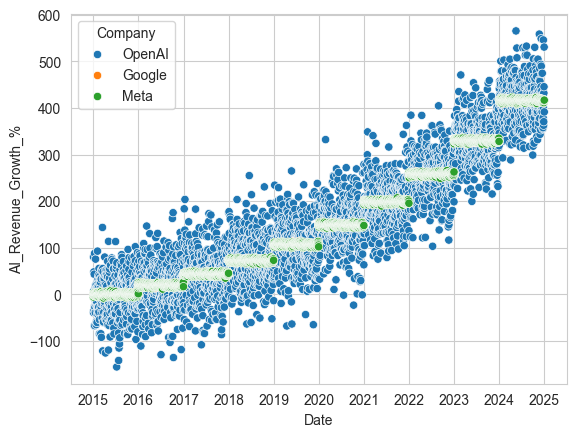

In [83]:
sns.scatterplot(data=data, x='Date' , y= 'AI_Revenue_Growth_%', hue='Company')

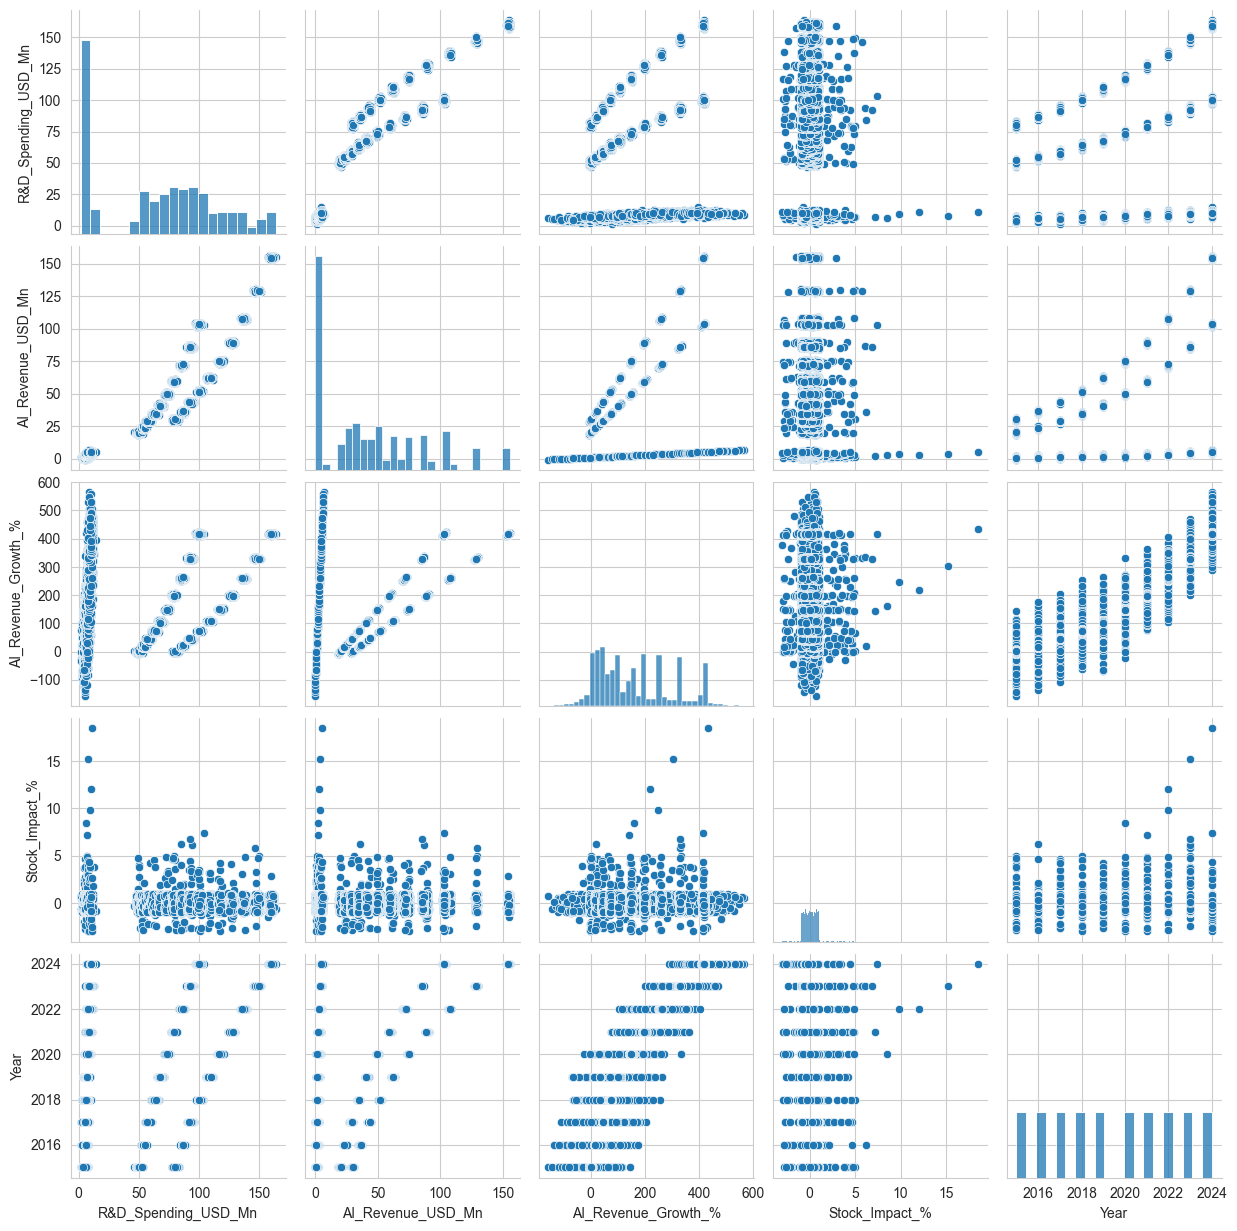

In [84]:
sns.pairplot(data)